<a href="https://colab.research.google.com/github/ChiaraTagiullo/Machine_Learning_for_NLP/blob/main/05_extension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extension: Analysis of Electoral Manifestos

In this extension, we move from structured metadata to raw political text.
The task is formulated as a binary classification problem:

**Predict political orientation (Left vs Right) from manifesto texts.**

## 1. Data Loading

We load manifesto texts from a compressed folder containing multiple `.txt` files about the 1988 Legislatives elections.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving legislatives (1).zip to legislatives (1).zip


In [2]:
import zipfile
import io

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(io.BytesIO(uploaded[zip_name]), 'r') as zip_ref:
    zip_ref.extractall('data')

In [3]:
import os

texts = []
filenames = []

for root, dirs, files in os.walk("data"):
    for file in files:
        if file.endswith(".txt"):
            path = os.path.join(root, file)
            with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                texts.append(f.read())
                filenames.append(file)

## 2. Data Preparation

We create a dataframe and assign labels (Left vs Right).

In [4]:
import pandas as pd

df = pd.DataFrame({
    "text": texts,
    "filename": filenames
})

df.head()

,text,filename
0,DEPARTEMENT DE L'OISE\n6ème CIRCONSCRIPTION\nC...,EL176_L_1988_06_060_06_1_PF_01.txt
1,LA FRANCE UNIE\nAVEC\nSciences Po / fonds CEVI...,EL177_L_1988_06_095_07_1_PF_03.txt
2,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,EL175_L_1988_06_034_01_1_PF_04.txt
3,Sciences Po / fonds CEVIPOF\nElections législa...,EL177_L_1988_06_095_03_2_PF_01.txt
4,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,EL176_L_1988_06_059_12_1_PF_03.txt


In [20]:
def assign_label(text):
    text = text.lower()

    # parole tipiche destra
    if "front national" in text or "le pen" in text or "contre le socialisme" in text:
        return "right"

    # parole tipiche sinistra
    elif "égalité" in text or "développement" in text or "communiste" in text:
        return "left"

    else:
        return "unknown"

In [22]:
df["label"] = df["text"].apply(assign_label)

In [23]:
df = df[df["label"] != "unknown"]

In [24]:
df["label"].value_counts()

,count
label,
left,1412
right,1190


## 3. Text Preprocessing

We clean the raw text by removing noise and normalizing content.

In [25]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœ ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

## 4. Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

## 5. Feature Extraction (TF-IDF)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## 6. Model Training

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

## 7. Evaluation

In [29]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        left       0.90      0.95      0.92       283
       right       0.94      0.87      0.90       238

    accuracy                           0.92       521
   macro avg       0.92      0.91      0.91       521
weighted avg       0.92      0.92      0.92       521



### Interpretation

The model achieves an overall accuracy of 0.92, indicating strong performance on the manifesto classification task.

Looking at class-specific metrics:

- **Left class**:
  - Precision: 0.90
  - Recall: 0.95
  - F1-score: 0.92  
  The high recall suggests that most left-wing manifestos are correctly identified.

- **Right class**:
  - Precision: 0.94
  - Recall: 0.87
  - F1-score: 0.90  
  The slightly lower recall indicates that some right-wing texts are misclassified as left.

The macro and weighted averages are both around 0.92, confirming a balanced and robust performance across classes.

Overall, the model performs well, with only minor asymmetry between the two classes.

## 8. Confusion Matrix

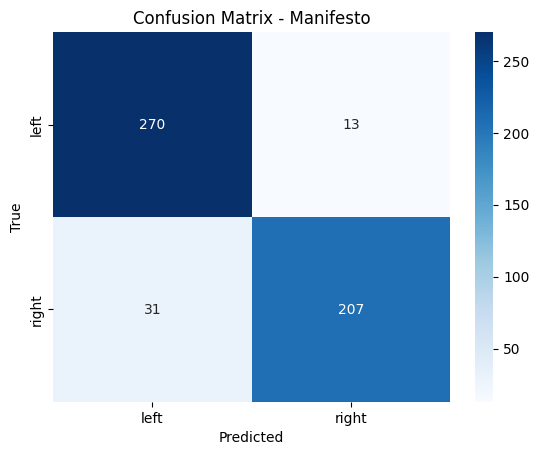

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Manifesto")

plt.savefig("confusion_matrix_manifesto.png")
plt.show()

### Interpretation

The confusion matrix provides a more detailed view of classification errors:

- **Left texts**:
  - 270 correctly classified
  - 13 misclassified as right

- **Right texts**:
  - 207 correctly classified
  - 31 misclassified as left

The model shows better performance on the left class, with fewer misclassifications.  
In contrast, right-wing manifestos are more frequently confused with left-wing ones.

This suggests that some right-wing texts may use less distinctive or more ambiguous language, making them harder to classify.

Overall, the number of errors remains low, confirming the strong predictive capability of the model.

## 9. Top Words

In [31]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_right = sorted(zip(coefficients, feature_names), reverse=True)[:15]
top_left = sorted(zip(coefficients, feature_names))[:15]

print("TOP RIGHT WORDS:")
for coef, word in top_right:
    print(word, coef)

print("\nTOP LEFT WORDS:")
for coef, word in top_left:
    print(word, coef)

TOP RIGHT WORDS:
front 4.812679127606065
national 3.9717980049233157
cevipov 3.111716815520611
pen 2.6551653279371923
droite 2.583185444071593
le 2.335245612379134
de 1.6953441911731102
pas 1.4578499188437628
française 1.2610308143366151
gauche 1.2551985051808165
qui 1.209126970409673
forces 1.1842482395874059
par 1.1423075919382417
neuf 1.133020591381444
pour 1.119495879728531

TOP LEFT WORDS:
développement -1.6645760859430159
notre -1.5358082311023078
saint -1.2021253590140764
nos -1.1563261975577406
président -1.1005681324664705
ai -1.0529688042588419
dans -0.9974228194939675
solidarité -0.9477613782038039
économique -0.9240760391597266
réunion -0.9065075802081985
région -0.8957720715857139
ma -0.8513271307498373
sa -0.8362772622602874
entre -0.8070350787092555
cœur -0.795179129194934


### Most Informative Words

The analysis of the most informative features reveals clear lexical differences between political orientations.

#### Right-wing vocabulary

Words with the highest positive coefficients include:

- *front*, *national*, *pen*, *droite*, *française*

These terms reflect:
- strong references to national identity
- mentions of specific political actors (e.g., Front National, Le Pen)
- a discourse centered on political positioning and ideological opposition

#### Left-wing vocabulary

Words with the most negative coefficients include:

- *développement*, *solidarité*, *économique*, *réunion*

These words indicate:
- a focus on economic and social policies
- emphasis on collective values such as solidarity
- attention to regional and development-related issues

#### Interpretation

The model successfully captures ideological distinctions through vocabulary usage.  
Right-wing texts tend to emphasize identity and political positioning, while left-wing texts focus more on socio-economic themes.

This highlights the effectiveness of simple lexical features (TF-IDF) in identifying underlying political orientations in textual data.

## Conclusion

In this extension, we moved from structured metadata to raw manifesto texts, formulating a binary classification task to predict political orientation.

Despite the increased complexity of working with unstructured textual data, the model achieves strong performance, with an accuracy of 0.92. This confirms that lexical features extracted through TF-IDF are sufficient to capture meaningful ideological differences in political discourse.

The analysis of classification errors shows that right-wing texts are slightly more difficult to identify, likely due to greater variability or overlap in vocabulary. In contrast, left-wing manifestos tend to use more distinctive socio-economic terminology, leading to higher recall.

The examination of the most informative words further supports this interpretation. Right-wing discourse is characterized by references to national identity and political actors, while left-wing texts emphasize development, solidarity, and economic concerns.

Compared to the previous analysis based on structured metadata, this extension highlights the challenges of working with real-world text, including noise and less standardized language. However, it also demonstrates the added value of textual analysis, providing deeper insights into the content and framing of political messages.

Overall, this experiment shows that even simple NLP techniques can effectively model political orientation from raw text, making them a valuable complement to traditional data analysis approaches.